# Evaluation — SisFall test set

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rokhaya8/fall-detection-lstm/blob/main/notebooks/05_evaluation_sisfall.ipynb)

Part of [fall-detection-lstm](https://github.com/Rokhaya8/fall-detection-lstm). Paths are set by `BASE_DIR` in the first code cell — adapt it to your Google Drive.

# Montage du drive

In [1]:
# 1. Montage du drive
from google.colab import drive
drive.mount('/content/drive')

# ── Dossier du projet dans Google Drive (à adapter si besoin) ──
import os
BASE_DIR = '/content/drive/MyDrive/Projet_Parkinson'
os.makedirs(f'{BASE_DIR}/Figures', exist_ok=True)


Mounted at /content/drive


# Téléchargement des données de Test

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Charger les données
X_test  = np.load(f'{BASE_DIR}/Data_Preprocessed/SisFall/X_test.npy')

y_test  = np.load(f'{BASE_DIR}/Data_Preprocessed/SisFall/y_test.npy')

print(f"X_test  : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_test  : (20367, 200, 6)
y_test : (20367,)


# TEST SUR LES DONNEES TEST

In [3]:
from tensorflow.keras.models import load_model
import numpy as np

# Chargement du modèle final
model = load_model(f'{BASE_DIR}/Models/LSTM_final.keras')
print("Modèle chargé ")

# Prédictions
y_pred_proba = model.predict(X_test)

# Seuil retenu : 0.40
y_pred = (y_pred_proba >= 0.40).astype(int)
print("Prédictions effectuées ")

Modèle chargé 
637/637 ━━━━━━━━━━━━━━━━━━━━ 47s 73ms/step
Prédictions effectuées 


# Calcul des métriques


=== MÉTRIQUES LSTM — SisFall (seuil=0.40) ===
Recall  : 0.820 (82.0%)
F1-score: 0.679 (67.9%)
FPR     : 0.291 (29.1%)

Matrice de confusion :
  TP : 5487 | FP : 3978
  FN : 1203 | TN : 9699


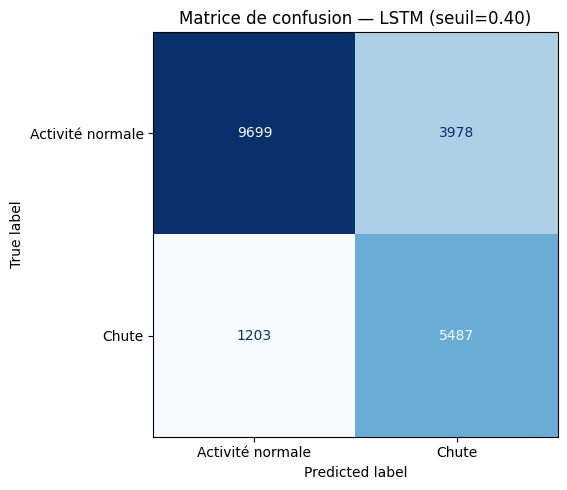

Matrice sauvegardée sur Drive

Latence LSTM : 107.625 ms/sample


In [6]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import time


# ===== Métriques =====
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

recall    = TP / (TP + FN)
f1        = 2 * TP / (2 * TP + FP + FN)
fpr       = FP / (FP + TN)

print("\n=== MÉTRIQUES LSTM — SisFall (seuil=0.40) ===")
print(f"Recall  : {recall:.3f} ({recall*100:.1f}%)")
print(f"F1-score: {f1:.3f} ({f1*100:.1f}%)")
print(f"FPR     : {fpr:.3f} ({fpr*100:.1f}%)")
print(f"\nMatrice de confusion :")
print(f"  TP : {TP} | FP : {FP}")
print(f"  FN : {FN} | TN : {TN}")

# ===== 4. Matrice de confusion visuelle =====
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Activité normale', 'Chute']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — LSTM (seuil=0.40)')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/Figures/confusion_matrix_lstm_sisfall.png', dpi=150)
plt.show()
print("Matrice sauvegardée sur Drive")

# ===== 5. Latence =====
sample = X_test[0:1]
start = time.time()
for _ in range(100):
    model.predict(sample, verbose=0)
end = time.time()
latence = (end - start) / 100 * 1000
print(f"\nLatence LSTM : {latence:.3f} ms/sample")